In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Load the Dataset
df = sns.load_dataset("titanic")

# Display first five rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**Observation**
The dataset contains passenger information such as age, sex, passenger class, fare, and survival status. The target variable is survived.

In [4]:
# Explore the Dataset

print("Display Dataset Shape",df.shape)

print("\n","Display Column Names")
print(df.columns)

print("\n","Dataset Information")
print(df.info())

print("\n","Summary Statistics")
print(df.describe().round(2))

Display Dataset Shape (891, 15)

 Display Column Names
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

 Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-n

**Observation**
The Titanic dataset contains 891 rows and 15 columns. It includes passenger information such as age, gender, passenger class, fare, and survival status. The target variable is survived, which shows whether a passenger survived (1) or did not survive (0).

The dataset contains both numerical and categorical data. Some columns, such as age, embarked, deck, and embark_town, have missing values that need to be handled during data preprocessing. The deck column has many missing values compared to the other columns.

From the summary statistics, the average age of the passengers is about 30 years, and the average fare is 32.20. The average value of the survived column is 0.38, which means about 38% of the passengers survived. Overall, the dataset is suitable for building a classification model after preprocessing.

In [5]:
#************************Data Preprocessing*******************************
# Check Missing Values
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


**Observation:**
The dataset contains missing values in columns such as age, embarked, deck, embark_town, and alive.

In [6]:
# Drop unnecessary columns
df.drop(['deck', 'alive', 'class', 'who', 'adult_male', 'embark_town'], axis=1, inplace=True)

**Observation**:
Unnecessary columns were removed to simplify the dataset and improve model performance.

In [7]:
# Fill Missing Age
df['age'] = df['age'].fillna(df['age'].median())

**Observation:**
Missing values in the Age column were replaced with the median age.

In [8]:
# Fill Missing Embarked
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

**Observation:**
Missing values in the Embarked column were replaced with the most frequent value.

In [9]:
# Check Missing Values Again
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
alone,0


**Observation:**
All missing values have been handled successfully.

In [10]:
# Check Duplicate Records
print("Duplicate Records: ",df.duplicated().sum())

# If duplicates exist:
df.drop_duplicates(inplace=True)

# Check again duplicate records
print("Check again:")
print(df.duplicated().sum())

Duplicate Records:  116
Check again:
0


**Observation:** The dataset had 116 duplicate records, which were successfully removed. After checking again, no duplicate records were found, ensuring better data quality for model training.

In [11]:
# Encode Categorical Variables
leEn = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = leEn.fit_transform(df[col])

print(df.head())

   survived  pclass  sex   age  sibsp  parch     fare  embarked  alone
0         0       3    1  22.0      1      0   7.2500         2  False
1         1       1    0  38.0      1      0  71.2833         0  False
2         1       3    0  26.0      0      0   7.9250         2   True
3         1       1    0  35.0      1      0  53.1000         2  False
4         0       3    1  35.0      0      0   8.0500         2   True


**Observation**
All categorical variables were converted into numerical values using Label Encoding.

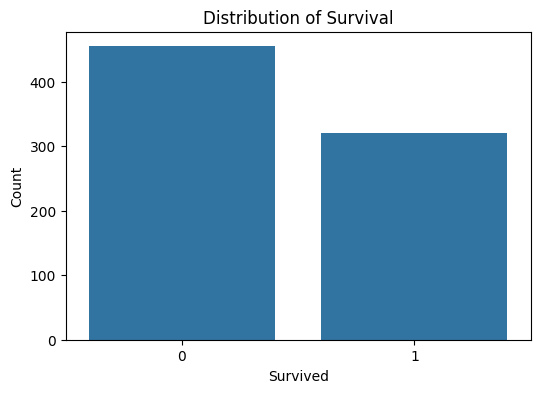

In [12]:
#************************Part2 Exploratory Data Analysis (EDA)********************************************

#Distribution of Survival

plt.figure(figsize=(6,4))
sns.countplot(x='survived', data=df)

plt.title("Distribution of Survival")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

**Observation:**
The graph shows the number of passengers who survived and those who did not survive. More passengers did not survive than survived.

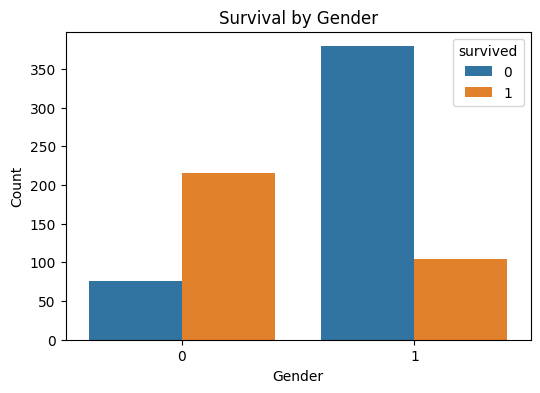

In [13]:
# Survival by Gender

plt.figure(figsize=(6,4))
sns.countplot(x='sex', hue='survived', data=df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

**Observation**
Female passengers had a higher survival rate than male passengers. Most passengers who did not survive were males.

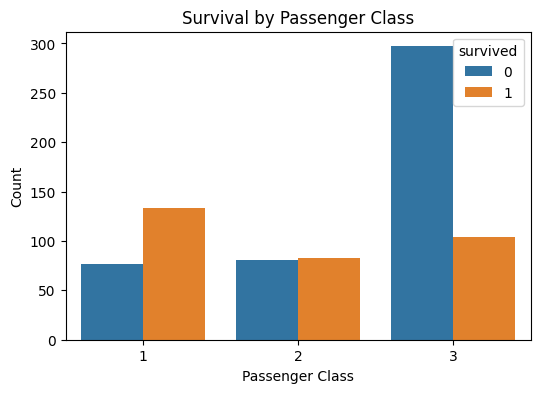

In [14]:
# Survival by Passenger Class
plt.figure(figsize=(6,4))
sns.countplot(x='pclass', hue='survived', data=df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

**Observation:**
Passengers travelling in First Class had a higher survival rate than passengers in Second and Third Class. Most passengers who did not survive were in Third Class.

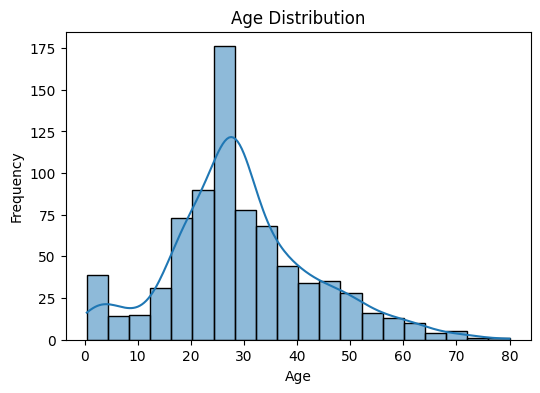

In [15]:
# Age Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

**Observation:**
Most passengers were between 20 and 40 years old. There were fewer children and elderly passengers.

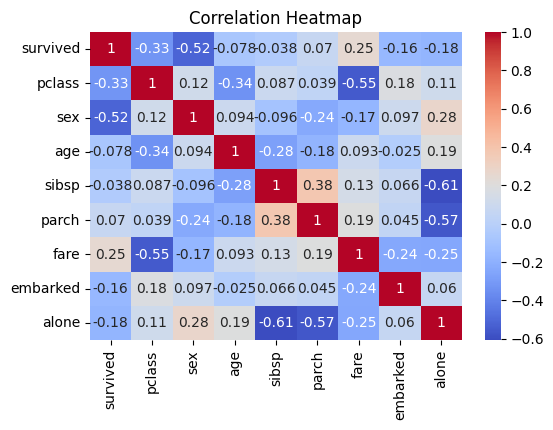

In [39]:
# Correlation Heatmap

plt.figure(figsize=(6,4))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

**Observation:**
The heatmap shows the relationship between different features. Features such as sex, pclass, and fare have a stronger relationship with the survived column, making them useful for predicting passenger survival.

In [17]:
#************************************Task3 Model_Building****************************************************************

# Select Features and Target Variable

X = df.drop('survived', axis=1)
y = df['survived']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (775, 8)
Target Shape: (775,)


**Observation:**
The dataset was divided into features (X) and the target variable (y). The features contain the passenger information, while the target variable (survived) indicates whether a passenger survived or not.

In [18]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (620, 8)
Testing Data: (155, 8)


**Observation:**
The dataset was divided into 80% training data and 20% testing data. The training data is used to build the model, while the testing data is used to evaluate its performance.

In [19]:
# Train the Model

X = df.drop('survived', axis=1)
y = df['survived']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Logistic Regression
logreg_model = LogisticRegression(max_iter=1000)

logreg_model.fit(X_train, y_train)

# Prediction

logreg_pred = logreg_model.predict(X_test)
print(logreg_pred)

[0 0 0 1 1 1 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 1 0 1 1 1 1 0 1 1 0 0 1 1 1 0 1
 0 1 0 1 0 0 0 0 1 0 1 1 0 0 1 0 0 0 0 0 1 1 1 0 1 1 1 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 1 1 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 1
 0 1 0 0 1 0 0 0 0 0 1 0 0 0 1 1 1 0 0 1 0 0 1 0 0 0 1 0 0 1 0 1 1 1 0 0 0
 1 1 0 0 1 0 0]


**Observation:** The Logistic Regression model successfully predicted the survival status of the passengers. The predicted values (0 and 1) represent passengers who did not survive and those who survived, respectively. These predictions will be evaluated using accuracy, classification report, and confusion matrix.

In [20]:
# Accuracy

logreg_accuracy = accuracy_score(y_test, logreg_pred)

print("Accuracy:", logreg_accuracy)

Accuracy: 0.7741935483870968


**Observation:**
The Logistic Regression model achieved an accuracy of 77.42%. This means the model correctly predicted whether a passenger survived or not for about 77 out of every 100 passengers. This indicates that the model performs reasonably well in predicting passenger survival.

In [21]:
# Classification Report

print(classification_report(y_test, logreg_pred))

              precision    recall  f1-score   support

           0       0.82      0.81      0.81        95
           1       0.70      0.72      0.71        60

    accuracy                           0.77       155
   macro avg       0.76      0.76      0.76       155
weighted avg       0.77      0.77      0.77       155



**Observation:** The Logistic Regression model achieved an accuracy of 77%, which means it correctly predicted the survival status of about 77 out of every 100 passengers. For passengers who did not survive (Class 0), the model performed well with a precision of 82%, recall of 81%, and an F1-score of 81%. For passengers who survived (Class 1), the model achieved a precision of 70%, recall of 72%, and an F1-score of 71%. Overall, the model performed better at predicting passengers who did not survive than those who survived, but it still showed good overall performance for this classification task.

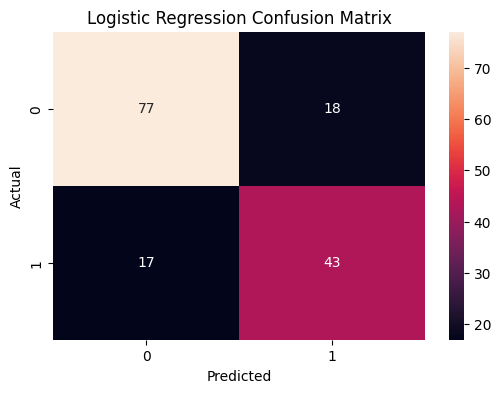

In [22]:
# Confusion Matrix

cm = confusion_matrix(y_test, logreg_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

**Explanation**
77 (Top Left - True Negative): The model correctly predicted 77 passengers who did not survive.
18 (Top Right - False Positive): The model incorrectly predicted 18 passengers as survived, but they actually did not survive.
17 (Bottom Left - False Negative): The model incorrectly predicted 17 passengers as not survived, but they actually survived.
43 (Bottom Right - True Positive): The model correctly predicted 43 passengers who survived.

In [23]:
#***************************** Decision Tree ***************************************
# define and train model

dectree_model = DecisionTreeClassifier(random_state=42)
dectree_model.fit(X_train, y_train)



DecisionTreeClassifier(random_state=42)

**Observation:**
The Decision Tree model was successfully trained using the training dataset.

In [28]:
# Prediction

dectree_pred =dectree_model.predict(X_test)

**Observation:**
The Decision Tree model predicted the survival status for the passengers in the testing dataset.

In [30]:
# Accuracy

dectree_accuracy = accuracy_score(y_test, dectree_pred)

print("Accuracy:", dectree_accuracy)

Accuracy: 0.7096774193548387


**Observation:** The Decision Tree model achieved an accuracy of 70.97%, which means it correctly predicted the survival status of about 71 out of every 100 passengers. Although the model performed reasonably well, its accuracy was lower than the Logistic Regression model, indicating that Logistic Regression performed better on this dataset.

In [31]:
# Classification Report

print(classification_report(y_test, dectree_pred))

              precision    recall  f1-score   support

           0       0.78      0.74      0.76        95
           1       0.62      0.67      0.64        60

    accuracy                           0.71       155
   macro avg       0.70      0.70      0.70       155
weighted avg       0.71      0.71      0.71       155



**Observation:** The Decision Tree model achieved an accuracy of 71%, which means it correctly predicted the survival status of about 71 out of every 100 passengers. For passengers who did not survive (Class 0), the model achieved a precision of 78%, recall of 74%, and an F1-score of 76%. For passengers who survived (Class 1), the model achieved a precision of 62%, recall of 67%, and an F1-score of 64%. The weighted average precision, recall, and F1-score were all 71%, indicating that the model performed reasonably well overall. However, compared with the Logistic Regression model (77% accuracy), the Decision Tree model was less accurate and less effective at predicting passenger survival.

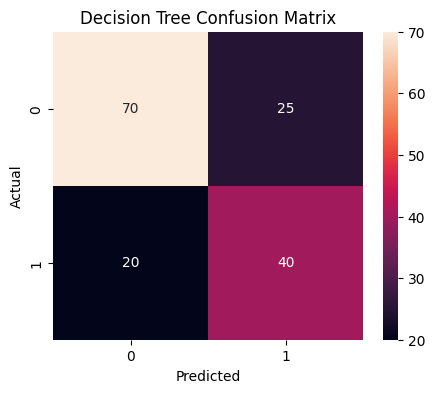

In [33]:
# Confusion Matrix

cm = confusion_matrix(y_test, dectree_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

**Observation:** The Decision Tree confusion matrix shows that the model correctly predicted 70 passengers who did not survive and 40 passengers who survived. However, it incorrectly predicted 25 passengers as survived when they actually did not survive and 20 passengers as not survived when they actually survived. Overall, the model made more correct predictions than incorrect ones, but it produced more misclassifications than the Logistic Regression model. This explains why the Decision Tree model achieved a lower accuracy of 71%, indicating that Logistic Regression performed better on this dataset.

In [34]:
# Compare Models

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [logreg_accuracy, dectree_accuracy]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.774194
1,Decision Tree,0.709677


**Observation:**
The comparison table shows the accuracy of both classification models. The Logistic Regression model achieved an accuracy of 77.42%, while the Decision Tree model achieved an accuracy of 70.97%. Since Logistic Regression has the higher accuracy, it performed better in predicting passenger survival on the Titanic dataset. Therefore, Logistic Regression is the better-performing model for this classification task and is the preferred model for deployment.

**Deployment Strategy:**
The Logistic Regression model achieved the highest accuracy (77.42%) and was selected as the best-performing model. This model can be deployed as a web application using Flask or FastAPI. Users can enter passenger details such as age, gender, passenger class, fare, and family information through a web interface. The model will process the input data and predict whether the passenger is likely to survive.

**Potential Issues During Deployment:**
During deployment, some problems may occur, such as missing or incorrect input data, changes in passenger data over time, or reduced model accuracy. To handle real-time data, the application should validate all user inputs before making predictions. If any required information is missing or invalid, the system should ask the user to correct it before generating a prediction.

**Model Monitoring and Maintenance**
After deployment, the model should be monitored regularly to ensure it continues to perform well. The prediction accuracy should be checked using new data, and the model should be retrained if its performance decreases. Monitoring prediction errors, validating incoming data, and updating the model periodically will help maintain accurate and reliable predictions.

Git Hub Link :